In [1]:
# System and path configuration
import sys
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
# Add parent directory to path for module imports
sys.path.insert(0, os.path.abspath('../..'))

# Core LSD imports
from codes.lsd_train import LSD
from codes.utils import (
    plot_random_walks,
    cross_boundary_correctness
)
from codes.config import LSDConfig
# Scientific computing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Deep learning
import torch
import torch.nn as nn
import pyro

# Single-cell analysis
import scanpy as sc
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [2]:
#read the adata
data_path = "../../data/BoneMarrow/normalized_before_low.h5ad"
adata = sc.read(data_path)

#intialize LSD model
cfg = LSDConfig()
lsd = LSD(
    adata,
    cfg,
    device=device,
    lib_size_key="librarysize",
    raw_count_key="raw"
)

#load the trained model
model_dir = "../../Models/BoneMarrow_model"
model_path = "lsd_model_epoch0200.pth"
lsd.load(model_dir, model_path)

#extract LSD outputs (transition matrix, potantial, entropy, pseudotime)
final_adata = lsd.get_adata()

#predict cell fates
dyn_adata = lsd.get_cell_fates(final_adata , time_range = 5, cluster_key = "clusters")

[LSD] Model and Pyro parameters loaded from ../../BoneMarrow_model/lsd_model_epoch0200.pth


/projects/apour/NDE311/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


plotting LSD outputs on tSNE projection


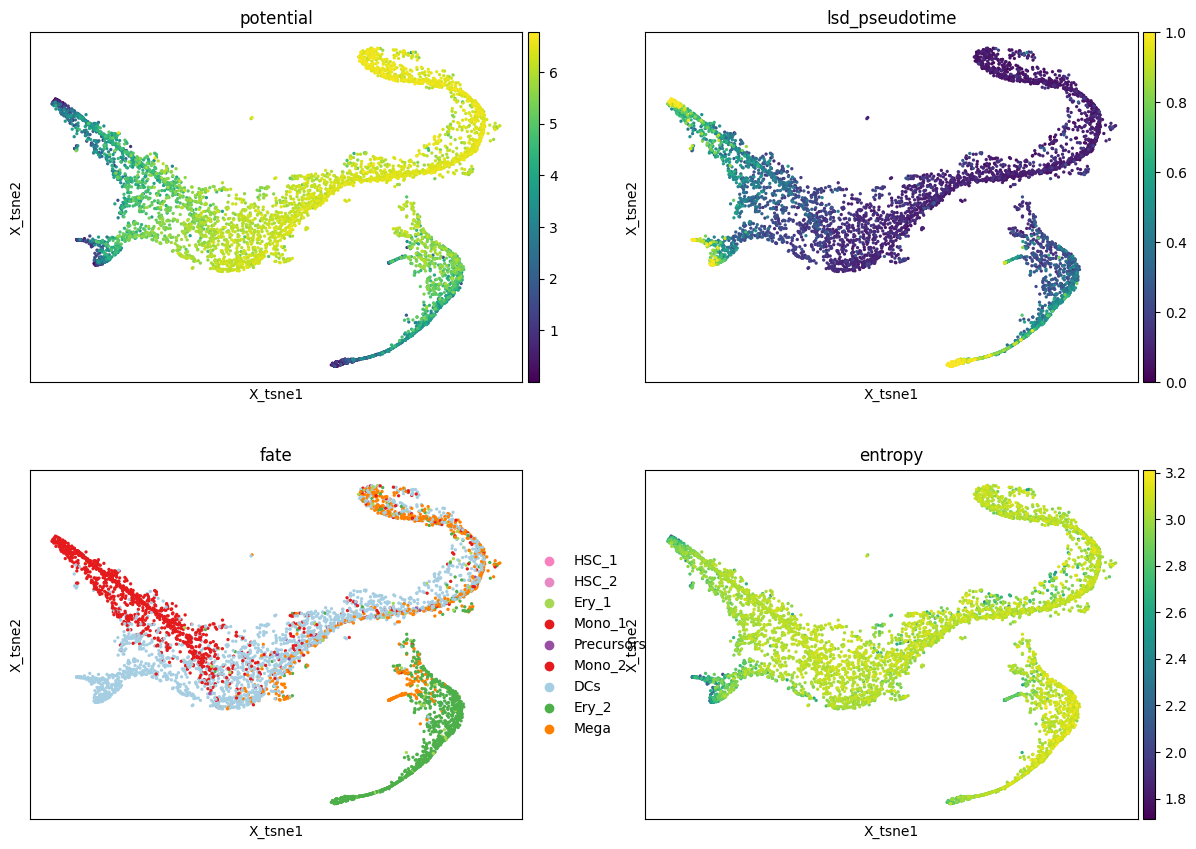

plotting LSD outputs on diffrentiation state projection


/projects/apour/NDE311/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


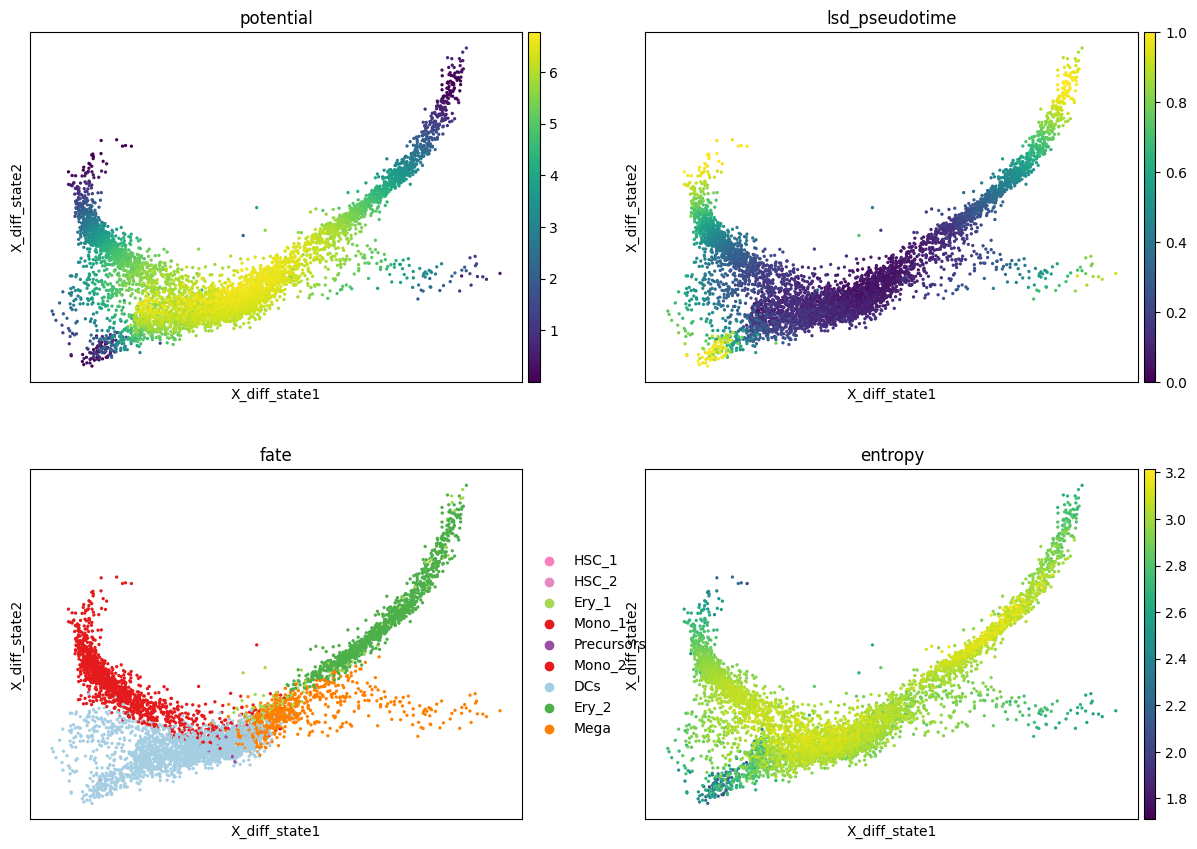

plotting LSD streamlines on tSNE projection


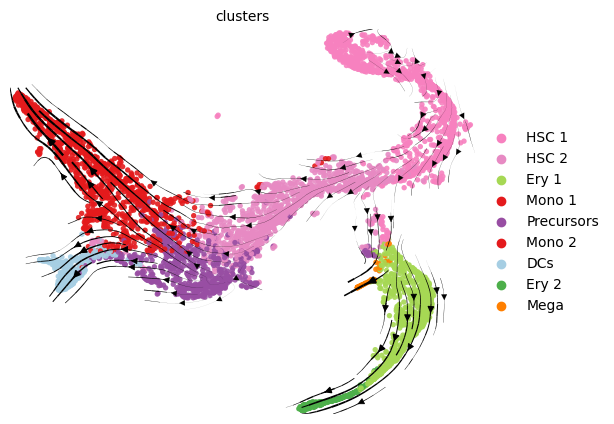

plotting LSD streamlines on diffrentiation state projection


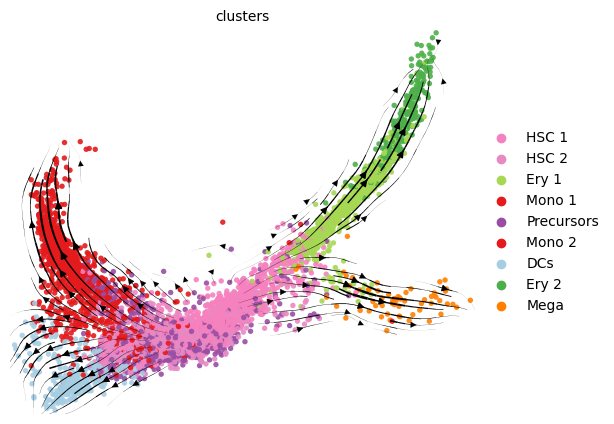

<Axes: title={'center': 'clusters'}>

In [3]:
#plot lsd outputs
dyn_adata.uns["fate_colors"] = dyn_adata.uns["clusters_colors"]
cols = ["potential", "lsd_pseudotime", "fate", "entropy"]

print("="* 60)
print("plotting LSD outputs on tSNE projection")
print("="* 60)
sc.pl.embedding(dyn_adata, color = cols, basis = "X_tsne", ncols = 2)

print("="* 60)
print("plotting LSD outputs on diffrentiation state projection")
print("="* 60)
sc.pl.embedding(dyn_adata, color = cols, basis = "X_diff_state", ncols = 2)

print("="* 60)
print("plotting LSD streamlines on tSNE projection")
print("="* 60)
lsd.stream_lines(embedding= "X_tsne", size = 60)

print("="* 60)
print("plotting LSD streamlines on diffrentiation state projection")
print("="* 60)
lsd.stream_lines(embedding= "X_diff_state", size = 60)

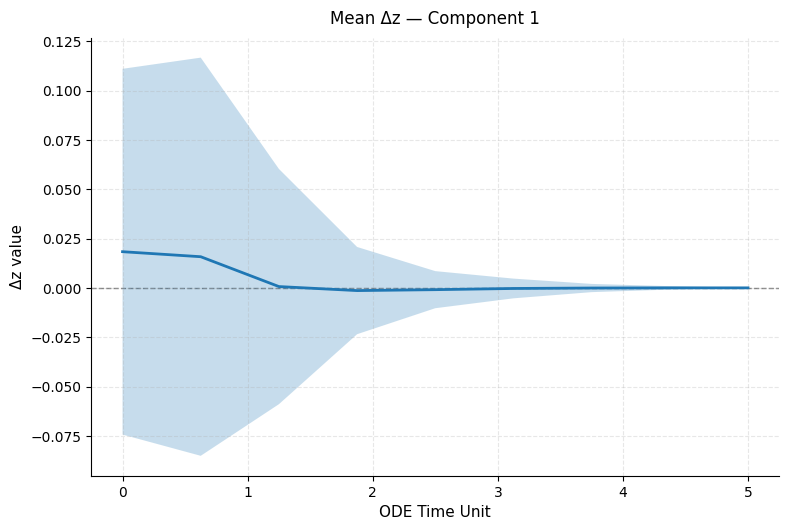

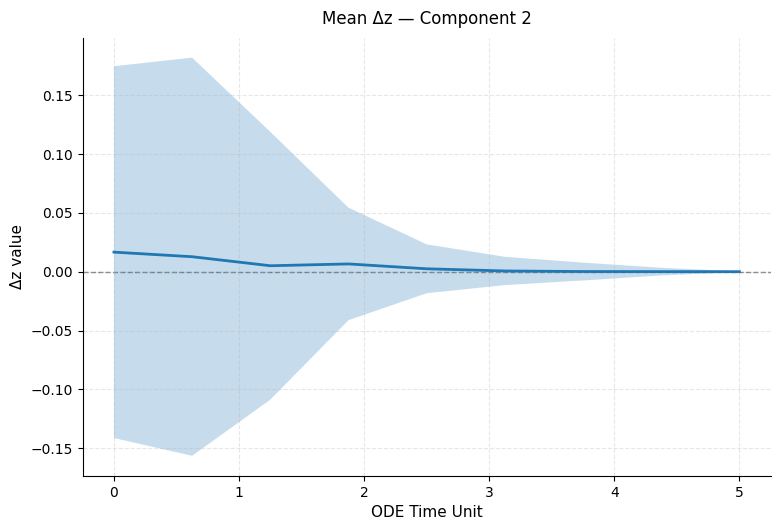

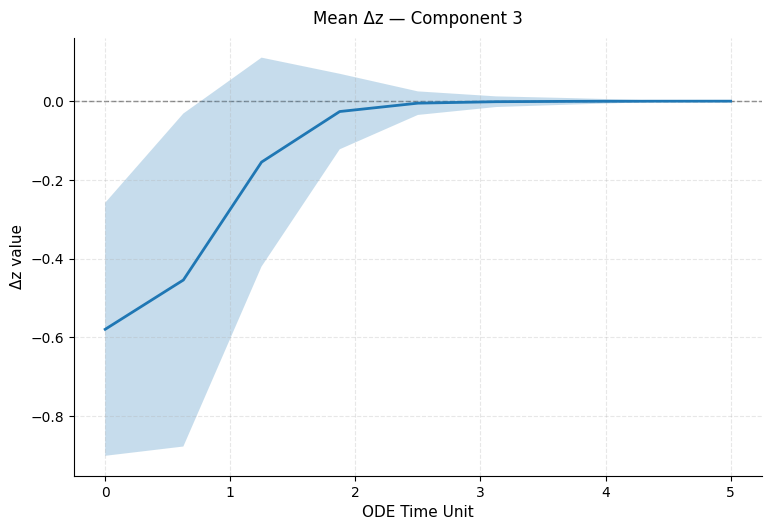

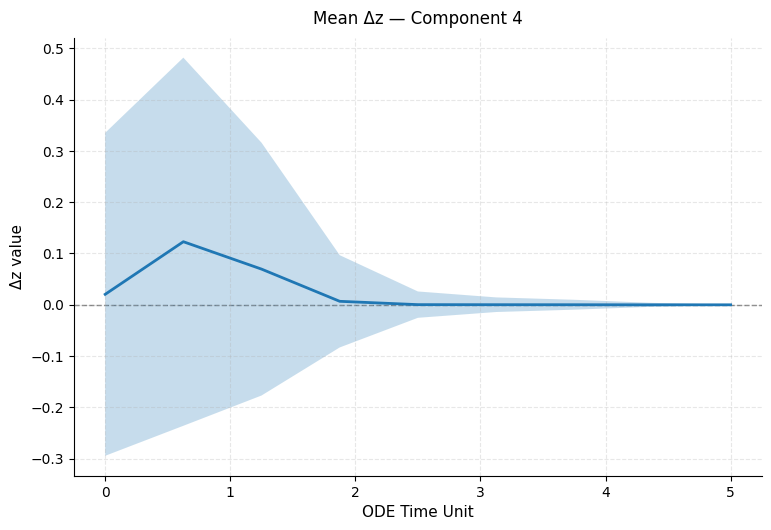

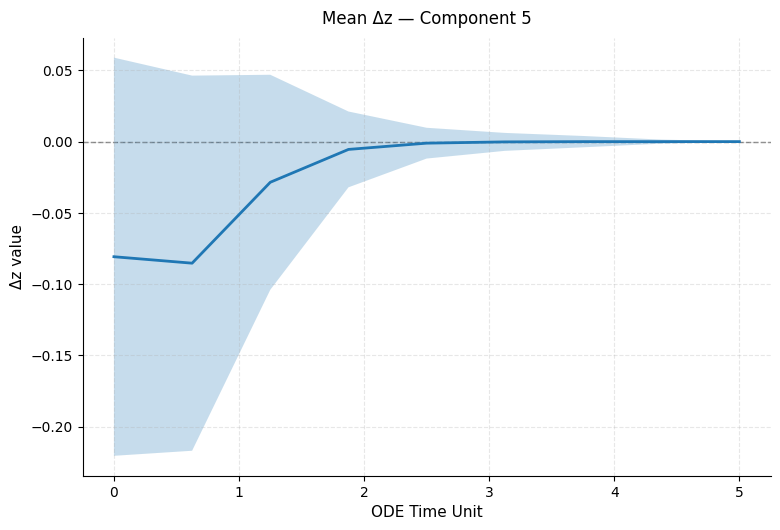

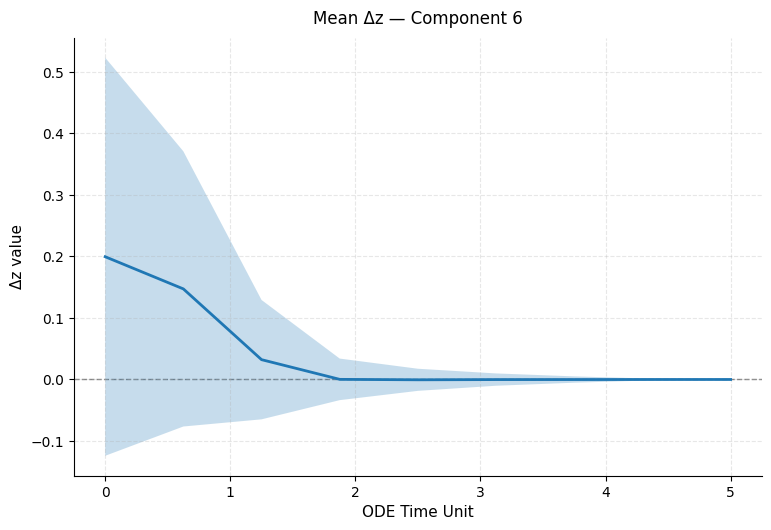

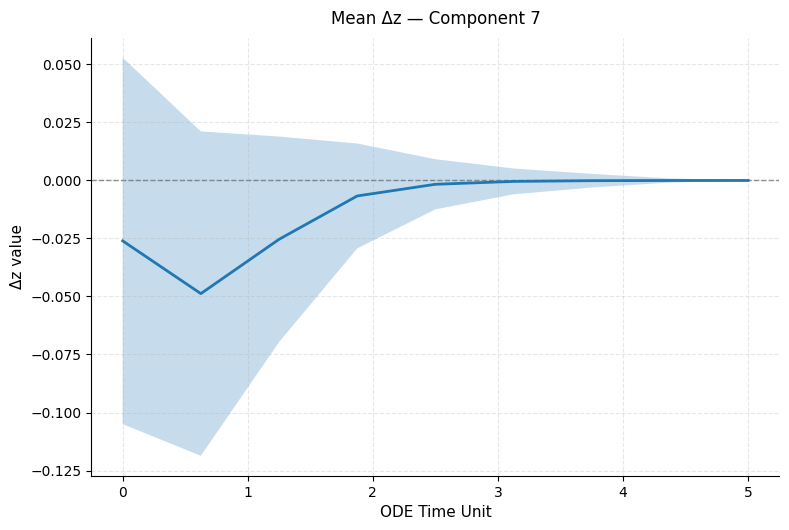

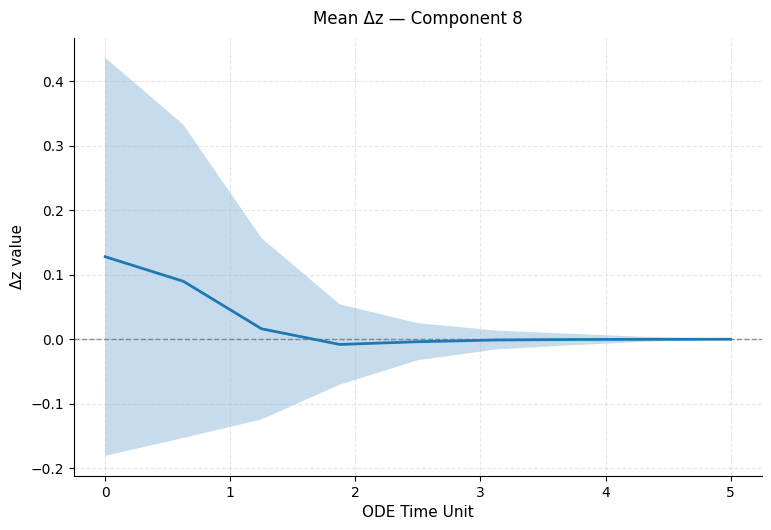

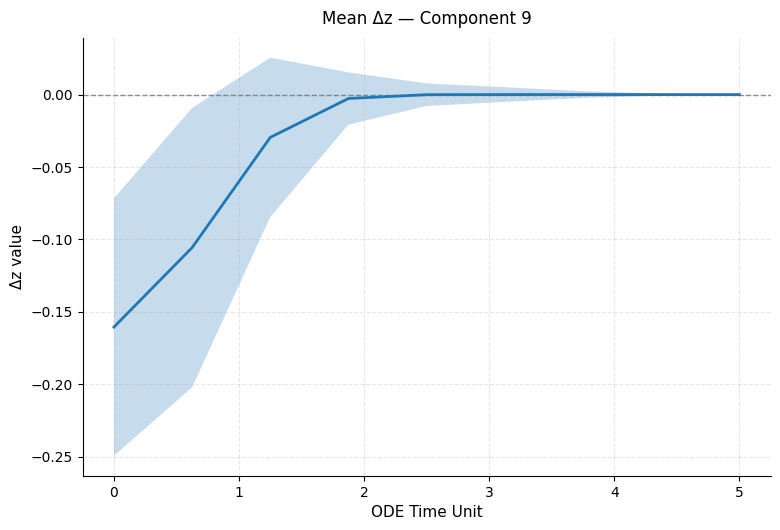

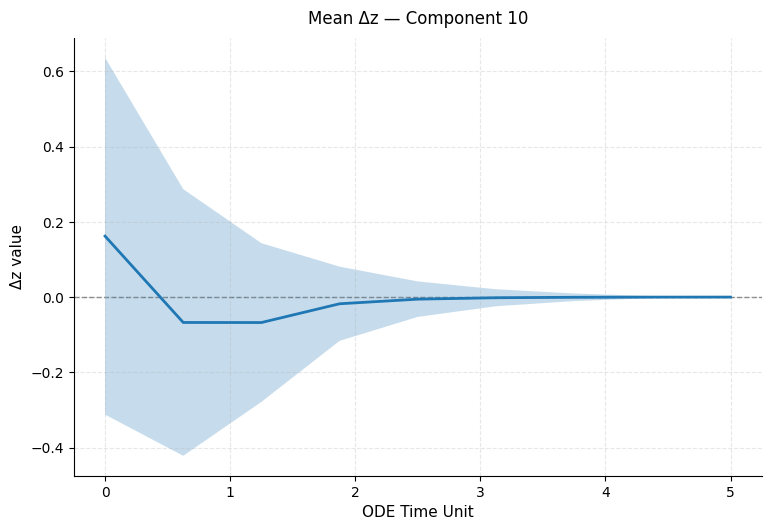

In [4]:
# plot Δz = z(t+1) - z(t), temporal changes of cell state
Z = lsd.z_sol.detach().cpu().numpy()
dZ = np.diff(Z, axis=0)
t = np.linspace(0, 5, dZ.shape[0])


for k in range(Z.shape[-1]):
    mean_k = dZ[:, :, k].mean(axis=1)
    std_k  = dZ[:, :, k].std(axis=1)
    fig, ax = plt.subplots(figsize=(8,6))
    ax.axhline(0, linestyle="--", linewidth=1.0, color="#666666", alpha=0.8, zorder=0)
    ax.plot(t, mean_k, linewidth=2)
    ax.fill_between(t, mean_k - std_k, mean_k + std_k, alpha=0.25, linewidth=0)
    ax.set_title(f"Mean Δz — Component {k+1}", fontsize=12, pad=10)
    ax.set_xlabel("ODE Time Unit", fontsize=11)
    ax.set_ylabel("Δz value", fontsize=11)
    ax.grid(True, alpha=0.3, linestyle="--")
    for s in ["top", "right"]: ax.spines[s].set_visible(False)
    for s in ["left", "bottom"]: ax.spines[s].set_linewidth(0.8)
    ax.tick_params(axis="both", labelsize=10)
    fig.subplots_adjust(top=0.88, left=0.12, right=0.98, bottom=0.15)
    plt.show()

In [5]:
# calculate CBDir
from cellrank.kernels import ConnectivityKernel
from cellrank.kernels.utils import TmatProjection
#define the cluster phylogeny
cluster_edges = [
    ("HSC_1", "HSC_2"),
    ("HSC_2", "Precursors"),
    ("HSC_1", "Ery_1"),
    ("Ery_1", "Ery_2"),
    ("Precursors", "Mono_1"),
    ("Precursors", "Mono_2"),
    ("Precursors", "DCs"),
]
#use cellrank for projecting velocity on tSNE embedding
kernel = ConnectivityKernel(final_adata)
kernel.transition_matrix = final_adata.obsp["transitions"]
proj = TmatProjection(kernel, basis="X_tsne")
proj.project(
    key_added="velocity_tsne",
    recompute=True,
    connectivities=final_adata.obsp["connectivities"]
)
# cellrank expects neighbor indices stored
indices = final_adata.obsp['distances'].tolil().rows
final_adata.uns['neighbors']['indices'] = indices

#measure CBDir
all_scores, metrics = cross_boundary_correctness(
    final_adata,
    k_cluster="clusters",
    k_velocity="velocity_tsne",
    cluster_edges=cluster_edges,
    x_emb="X_tsne"
)
# Display results
print("\nCross-boundary correctness scores:")
for edge, score in all_scores.items():
    print(f"  {edge}: {score:.3f}")

# Compute summary statistics
average_all = np.mean(list(all_scores.values()))

print(f"\nOverall average: {average_all:.3f}")


Cross-boundary correctness scores:
  ('HSC_1', 'HSC_2'): 0.331
  ('HSC_2', 'Precursors'): 0.498
  ('HSC_1', 'Ery_1'): 0.685
  ('Ery_1', 'Ery_2'): 0.834
  ('Precursors', 'Mono_1'): 0.555
  ('Precursors', 'Mono_2'): 0.458
  ('Precursors', 'DCs'): 0.799

Overall average: 0.594


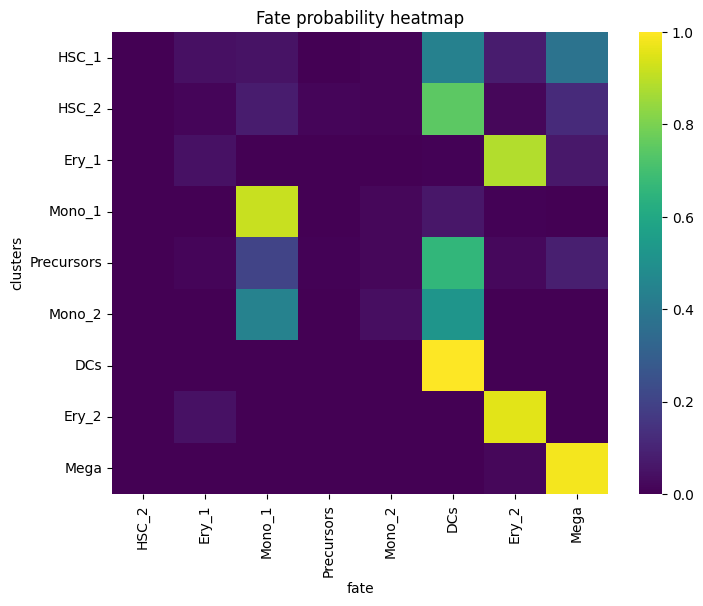

In [6]:
#plot fate probability heatmap
fate_df = pd.crosstab(dyn_adata.obs["clusters"], dyn_adata.obs["fate"], normalize= "index")
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(fate_df, cmap="viridis", ax=ax)
ax.set_title("Fate probability heatmap")
plt.show()

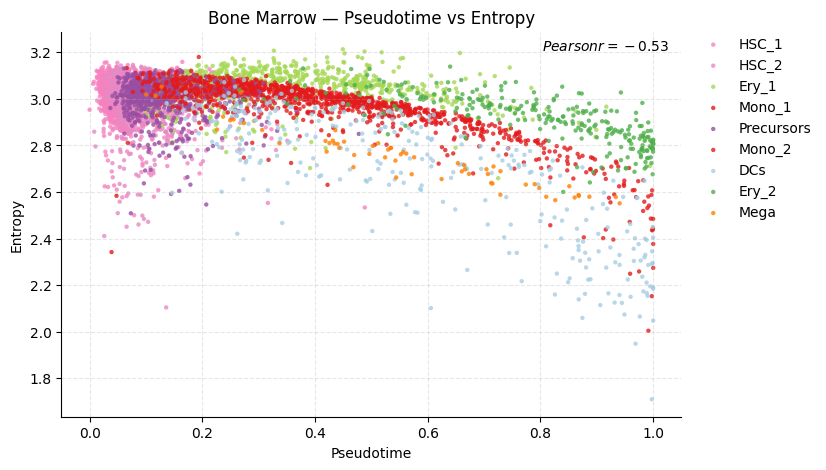

In [7]:
#Plot entropy vs pseudotime scatter plot
clusters = dyn_adata.obs["clusters"]
# Map cluster category → color
categories = clusters.cat.categories
cluster_colors = dyn_adata.uns["clusters_colors"]
palette = {cat: col for cat, col in zip(categories, cluster_colors)}

# Extract x, y
x = np.asarray(dyn_adata.obs["lsd_pseudotime"])
y = np.asarray(dyn_adata.obs["entropy"])

r = float(np.corrcoef(x, y)[0, 1])

fig, ax = plt.subplots(figsize=(8,5))

# Scatter by cluster, rasterized
cluster_vals = clusters.to_numpy()
for cat in categories:
    m = (cluster_vals == cat)
    if not np.any(m):
        continue
    ax.scatter(
        x[m],
        y[m],
        s=10,
        alpha=0.8,
        c=palette[cat],
        edgecolors="none",
        rasterized=True,
        label=str(cat),
    )

ax.set_xlabel("Pseudotime")
ax.set_ylabel("Entropy")
ax.set_title("Bone Marrow — Pseudotime vs Entropy")

# Pearson r in top-right
if np.isfinite(r):
    ax.text(
        0.98,
        0.98,
        rf"$Pearson r = {r:.2f}$",
        transform=ax.transAxes,
        ha="right",
        va="top",
    )

for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
for s in ["left", "bottom"]:
    ax.spines[s].set_linewidth(0.8)
ax.grid(True, alpha=0.3, linestyle="--")

ax.legend(
    frameon=False,
    bbox_to_anchor=(1.02, 1.0),
    loc="upper left",
    borderaxespad=0.0,
)
plt.show()
